In [9]:
import re
import string
import time
import warnings
import numpy as np
import pandas as pd
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, matthews_corrcoef,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [10]:
DATASET_PATH  = 'dataset.csv'   # change if needed
TEST_SIZE     = 0.20
RANDOM_STATE  = 42
TFIDF_FEATS   = 10_000
SMOTE_ENABLED = True                    # set False to skip SMOTE
SAVE_BEST     = True                    # save best model as best_model.pkl

In [11]:
df_raw = pd.read_csv(DATASET_PATH)
print(f'Raw shape : {df_raw.shape}')
df_raw.head(3)

Raw shape : (130382, 2)


,headline,label
0,realDonaldTrump Stop yelling..,0
1,"Junior school was St Andrew, St David, St Geor...",1
2,"hey! to anyone reading this, it is completely ...",1


In [13]:
lemmatizer = WordNetLemmatizer()
LEET_MAP = {'1':'i','3':'e','4':'a','@':'a','0':'o','$':'s','5':'s','7':'t'}

def normalize_leet(text: str) -> str:
    for k, v in LEET_MAP.items():
        text = text.replace(k, v)
    return text

def preprocess(text: str) -> str:
    text = str(text).lower()
    text = normalize_leet(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)          # URLs
    text = re.sub(r'@\w+', '', text)                       # mentions
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)            # non-ASCII
    text = text.translate(str.maketrans('', '', string.punctuation))  # punct
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)            # repeated chars
    text = re.sub(r'\d+', '', text)                        # digits
    words = [lemmatizer.lemmatize(w) for w in text.split()]
    return ' '.join(words).strip()

df = df_raw.copy()

# Accept both already-cleaned CSVs and raw ones
df = df[df['label'].isin([0, 1, '0', '1'])].copy()
df['label'] = df['label'].astype(int)
df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')], inplace=True, errors='ignore')
df.dropna(subset=['headline'], inplace=True)

# Only re-run full preprocessing on raw dataset; skip if already cleaned
sample_check = str(df['headline'].iloc[0])
needs_clean = any(c in sample_check for c in ['http', '@', '#', '<'])
if needs_clean:
    print('Applying full preprocessing pipeline...')
    df['headline'] = df['headline'].astype(str).apply(preprocess)
else:
    print('Dataset appears pre-cleaned — skipping heavy preprocessing.')

df.drop_duplicates(subset=['headline'], inplace=True)
df = df[df['headline'].str.len() > 2].reset_index(drop=True)

print(f'Clean shape : {df.shape}')
print(f'Label dist  :\n{df["label"].value_counts().rename({0:"Safe",1:"Threat"})}')

Dataset appears pre-cleaned — skipping heavy preprocessing.
Clean shape : (130380, 2)
Label dist  :
label
Threat    93212
Safe      37168
Name: count, dtype: int64


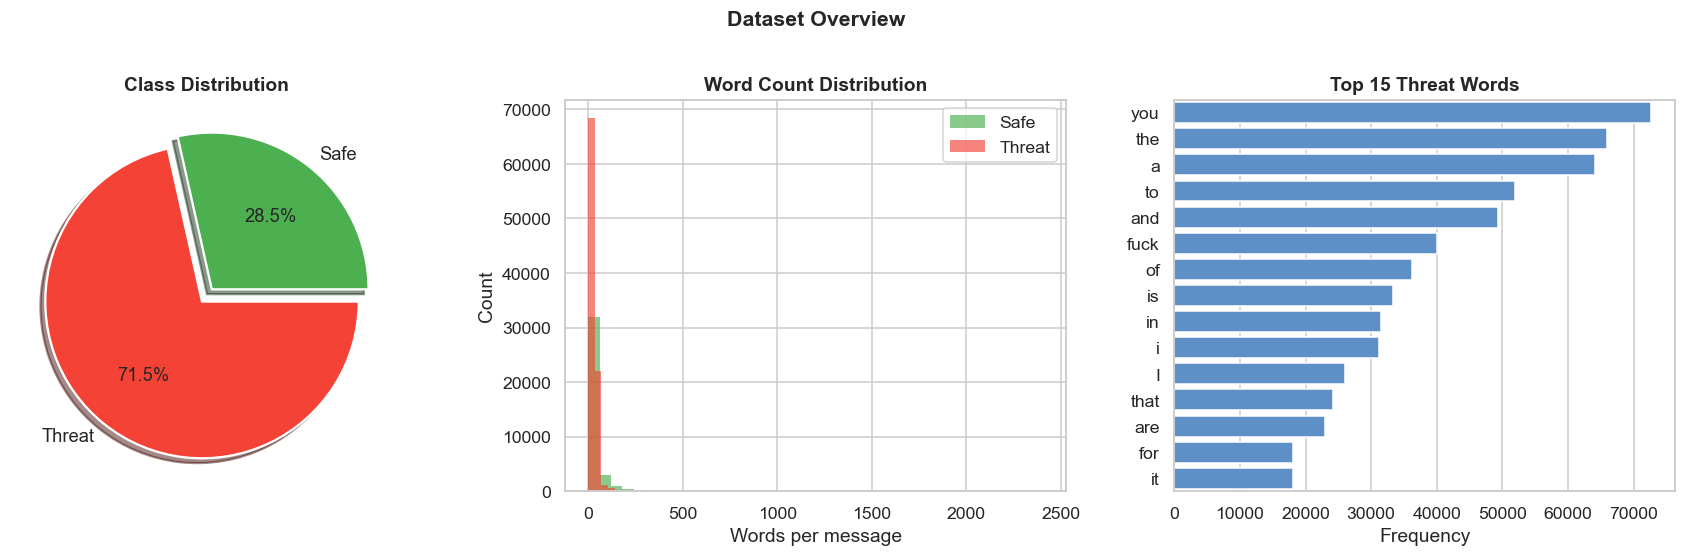

In [17]:
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold'})
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pie chart
total = len(df)
counts = df['label'].value_counts().sort_index()
colors = ['#4CAF50', '#F44336']
axes[0].pie(
    counts,
    labels=['Safe', 'Threat'],
    autopct='%1.1f%%',
    explode=[0.05, 0.05],
    colors=colors,
    shadow=True,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 12}
)
axes[0].set_title('Class Distribution')

# Text-length distribution
df['text_len'] = df['headline'].str.split().str.len()
for label, color, name in zip([0, 1], colors, ['Safe', 'Threat']):
    axes[1].hist(
        df.loc[df['label'] == label, 'text_len'],
        bins=40, alpha=0.65, color=color, label=name, edgecolor='none'
    )
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Words per message')
axes[1].set_ylabel('Count')
axes[1].legend()

# Top unigrams (threat class)
from collections import Counter
threat_words = ' '.join(df.loc[df['label']==1, 'headline']).split()
top_words = pd.Series(Counter(threat_words).most_common(15)).apply(pd.Series)
top_words.columns = ['word', 'freq']
sns.barplot(
    data=top_words,
    x='freq',
    y='word',
    color='#4A90D9',
    ax=axes[2]
)

axes[2].set_title('Top 15 Threat Words')
axes[2].set_xlabel('Frequency')
axes[2].set_ylabel('')

plt.suptitle('Dataset Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
df.drop(columns=['text_len'], inplace=True)

In [20]:
X_raw = df['headline']
y     = df['label'].astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

vectorizer = TfidfVectorizer(
    max_features=TFIDF_FEATS,
    stop_words='english',
    ngram_range=(1, 2),      # unigrams + bigrams
    sublinear_tf=True,       # log-scale TF
    min_df=3,
)

X_train = vectorizer.fit_transform(X_train_raw)
X_test  = vectorizer.transform(X_test_raw)

print(f'Train : {X_train.shape}   |   Test : {X_test.shape}')
print(f'Train label dist to 0: {(y_train==0).sum()}  1: {(y_train==1).sum()}')

Train : (104304, 10000)   |   Test : (26076, 10000)
Train label dist to 0: 29734  1: 74570


In [23]:
if SMOTE_ENABLED:
    sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
    X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
    print(f'After SMOTE to 0: {(y_train_bal==0).sum()}  1: {(y_train_bal==1).sum()}')
else:
    X_train_bal, y_train_bal = X_train, y_train
    print('SMOTE disabled — using original distribution.')

After SMOTE to 0: 74570  1: 74570


In [61]:
models = {
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, solver='lbfgs',
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=12, min_samples_leaf=5,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=3,
        n_jobs=-1, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=3,
        n_jobs=-1, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss',
        n_jobs=-1, random_state=RANDOM_STATE
    ),

    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced',
        n_jobs=-1, random_state=RANDOM_STATE,
        verbose=-1
    ),
}
NB_X_train = X_train
NB_y_train = y_train

print(f'Models registered: {list(models.keys())}')

Models registered: ['Naive Bayes', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM']


In [62]:
trained   = {}
train_times = {}

for name, model in models.items():
    Xtr = NB_X_train if name == 'Naive Bayes' else X_train_bal
    ytr = NB_y_train if name == 'Naive Bayes' else y_train_bal

    t0 = time.perf_counter()
    model.fit(Xtr, ytr)
    elapsed = time.perf_counter() - t0

    trained[name]     = model
    train_times[name] = round(elapsed, 3)
    print(f'  {name:<25} trained in {elapsed:.2f}s')

print('\nAll models trained.')

  Naive Bayes               trained in 0.02s
  Logistic Regression       trained in 1.05s
  Decision Tree             trained in 4.23s
  Random Forest             trained in 2.25s
  Extra Trees               trained in 1.79s
  XGBoost                   trained in 46.87s
  LightGBM                  trained in 7.19s

All models trained.


In [63]:
results = []
proba_store = {}   # for ROC / PR curves

for name, model in trained.items():
    y_pred = model.predict(X_test)

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())
    else:
        y_prob = y_pred.astype(float)

    proba_store[name] = y_prob

    results.append({
        'Model'        : name,
        'Accuracy'     : accuracy_score(y_test, y_pred),
        'Precision'    : precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall'       : recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1 Score'     : f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'ROC-AUC'      : roc_auc_score(y_test, y_prob),
        'MCC'          : matthews_corrcoef(y_test, y_pred),
        'Train Time(s)': train_times[name],
    })

results_df = (
    pd.DataFrame(results)
    .sort_values('F1 Score', ascending=False)
    .reset_index(drop=True)
)

# Styled display
def highlight_max(s):
    return ['background-color: #d4edda; font-weight: bold'
            if v == s.max() else '' for v in s]

numeric_cols = ['Accuracy','Precision','Recall','F1 Score','ROC-AUC','MCC']
results_df.style \
    .apply(highlight_max, subset=numeric_cols) \
    .format({c: '{:.4f}' for c in numeric_cols}) \
    .format({'Train Time(s)': '{:.3f}'})

E:\anacode3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anacode3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,MCC,Train Time(s)
0,Logistic Regression,0.849785,0.870981,0.849785,0.854622,0.929751,0.671908,1.046
1,Naive Bayes,0.828501,0.822988,0.828501,0.819763,0.910759,0.554289,0.020
2,XGBoost,0.798550,0.860471,0.798550,0.808023,0.903246,0.617201,46.872
3,LightGBM,0.797016,0.860469,0.797016,0.806603,0.903845,0.616033,7.193
4,Random Forest,0.758283,0.845327,0.758283,0.770015,0.896826,0.564266,2.248
5,Extra Trees,0.750882,0.849830,0.750882,0.762866,0.904415,0.565322,1.785
6,Decision Tree,0.691479,0.834293,0.691479,0.704348,0.781355,0.498875,4.227


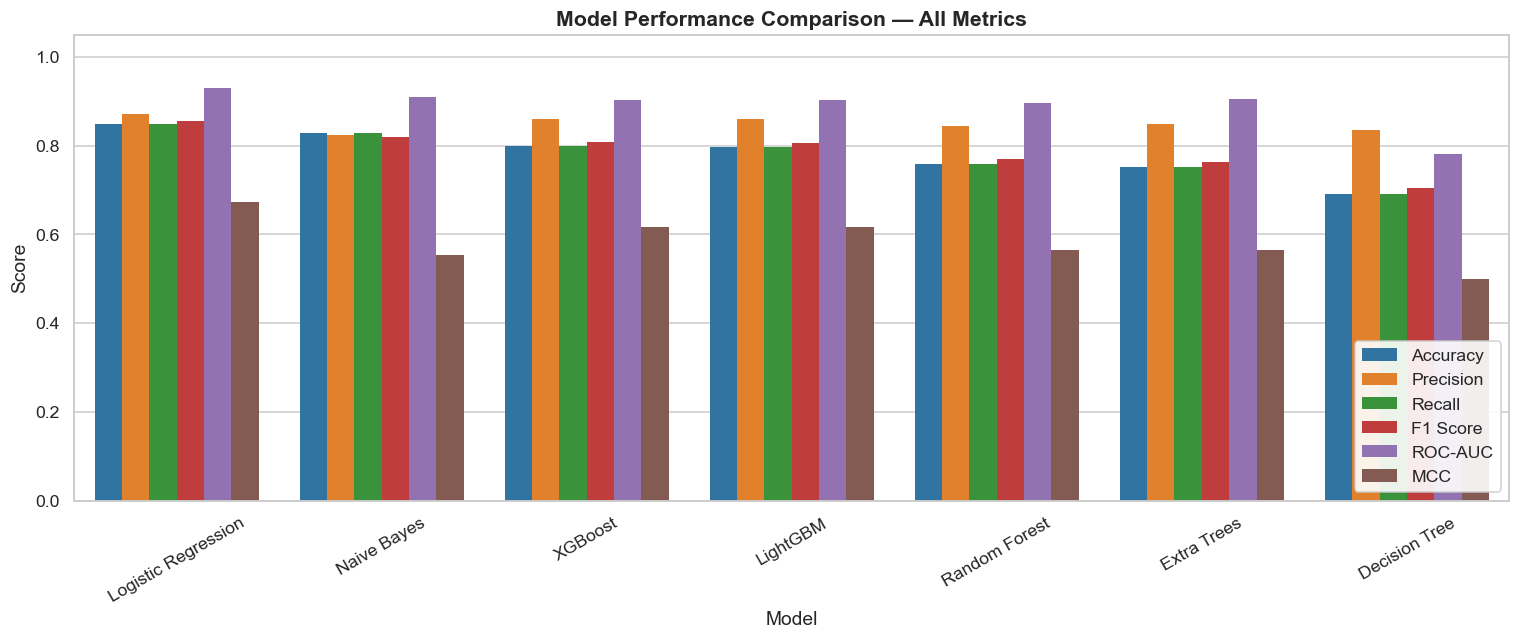

In [64]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'MCC']
df_melt = results_df.melt(id_vars='Model', value_vars=metrics,
                           var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=df_melt, x='Model', y='Score', hue='Metric',
            palette='tab10', ax=ax, edgecolor='none')

ax.set_title('Model Performance Comparison — All Metrics', fontsize=14)
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=30)
ax.legend(loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.show()

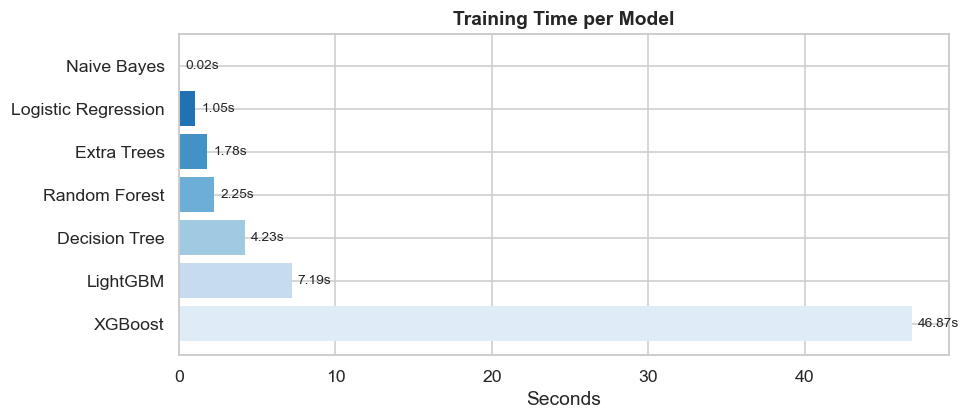

In [65]:
time_df = results_df[['Model', 'Train Time(s)']].sort_values('Train Time(s)')

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(time_df['Model'], time_df['Train Time(s)'],
               color=sns.color_palette('Blues_r', len(time_df)), edgecolor='none')
ax.bar_label(bars, fmt='%.2fs', padding=4, fontsize=9)
ax.set_xlabel('Seconds')
ax.set_title('Training Time per Model')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

E:\anacode3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


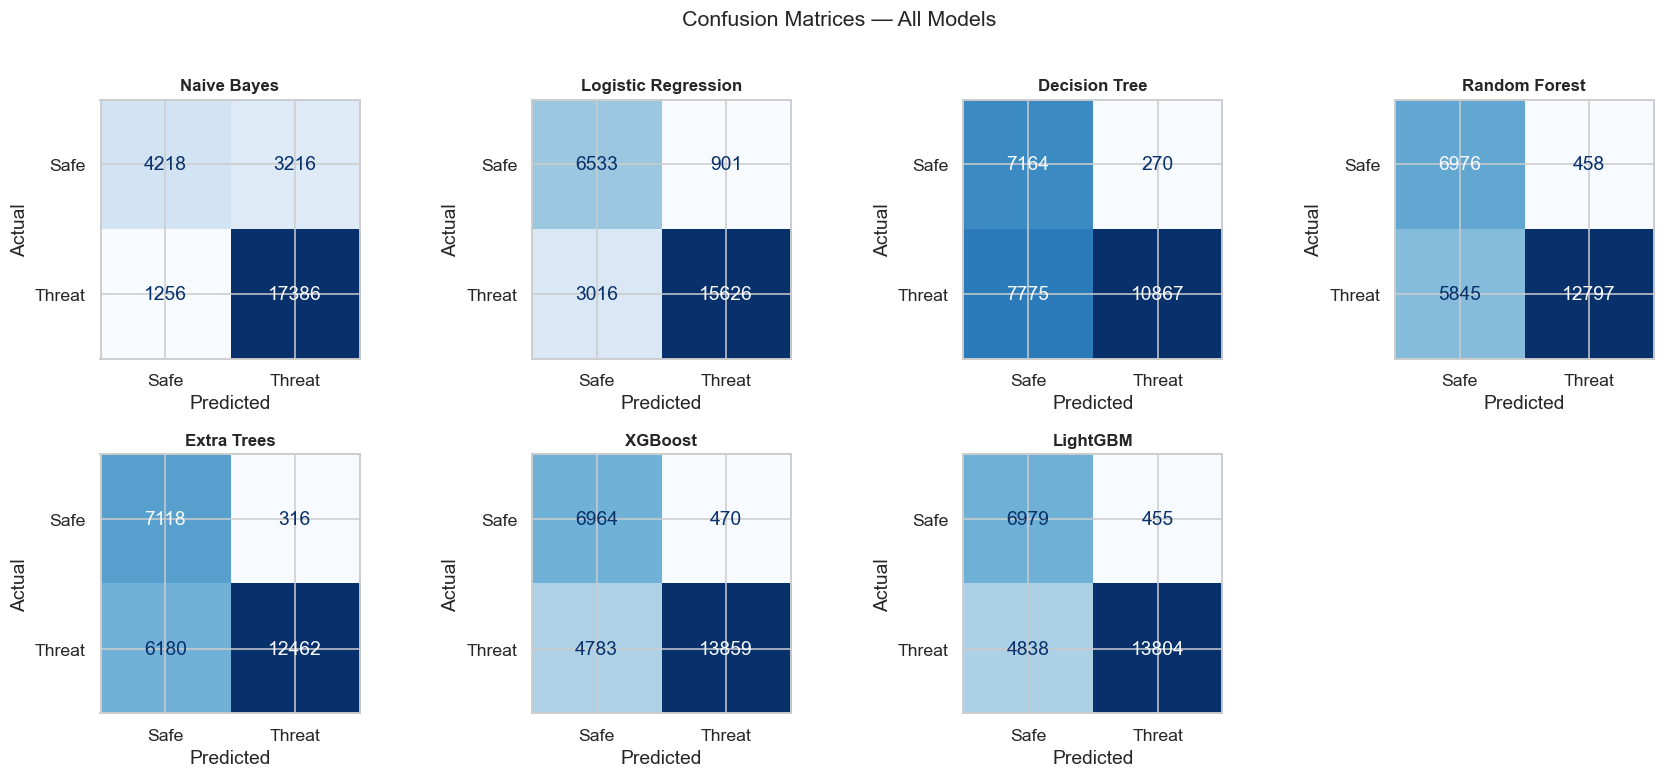

In [66]:
n_models = len(trained)
cols = 4
rows = (n_models + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
axes = axes.flatten()

for i, (name, model) in enumerate(trained.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Safe', 'Threat'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontsize=11)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

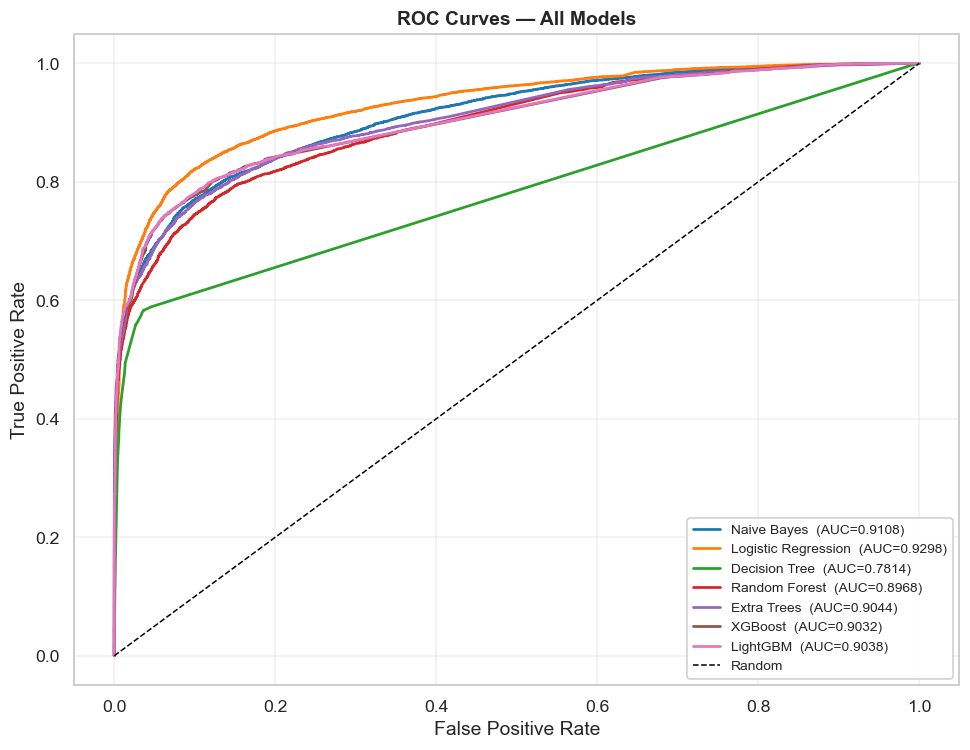

In [67]:
fig, ax = plt.subplots(figsize=(9, 7))
palette = sns.color_palette('tab10', len(trained))

for (name, y_prob), color in zip(proba_store.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name}  (AUC={auc:.4f})', color=color, lw=1.8)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right', fontsize=9, framealpha=0.95)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

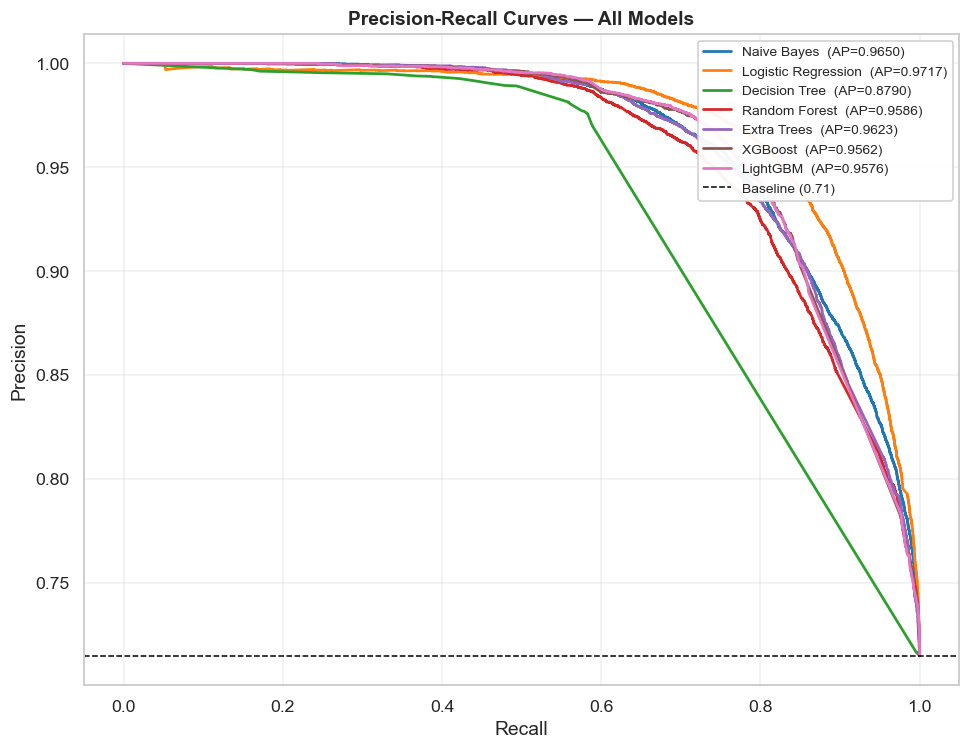

In [68]:
fig, ax = plt.subplots(figsize=(9, 7))
palette = sns.color_palette('tab10', len(trained))

for (name, y_prob), color in zip(proba_store.items(), palette):
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(recall, precision, label=f'{name}  (AP={ap:.4f})', color=color, lw=1.8)

baseline = y_test.mean()
ax.axhline(baseline, color='k', linestyle='--', lw=1, label=f'Baseline ({baseline:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models')
ax.legend(loc='upper right', fontsize=9, framealpha=0.95)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

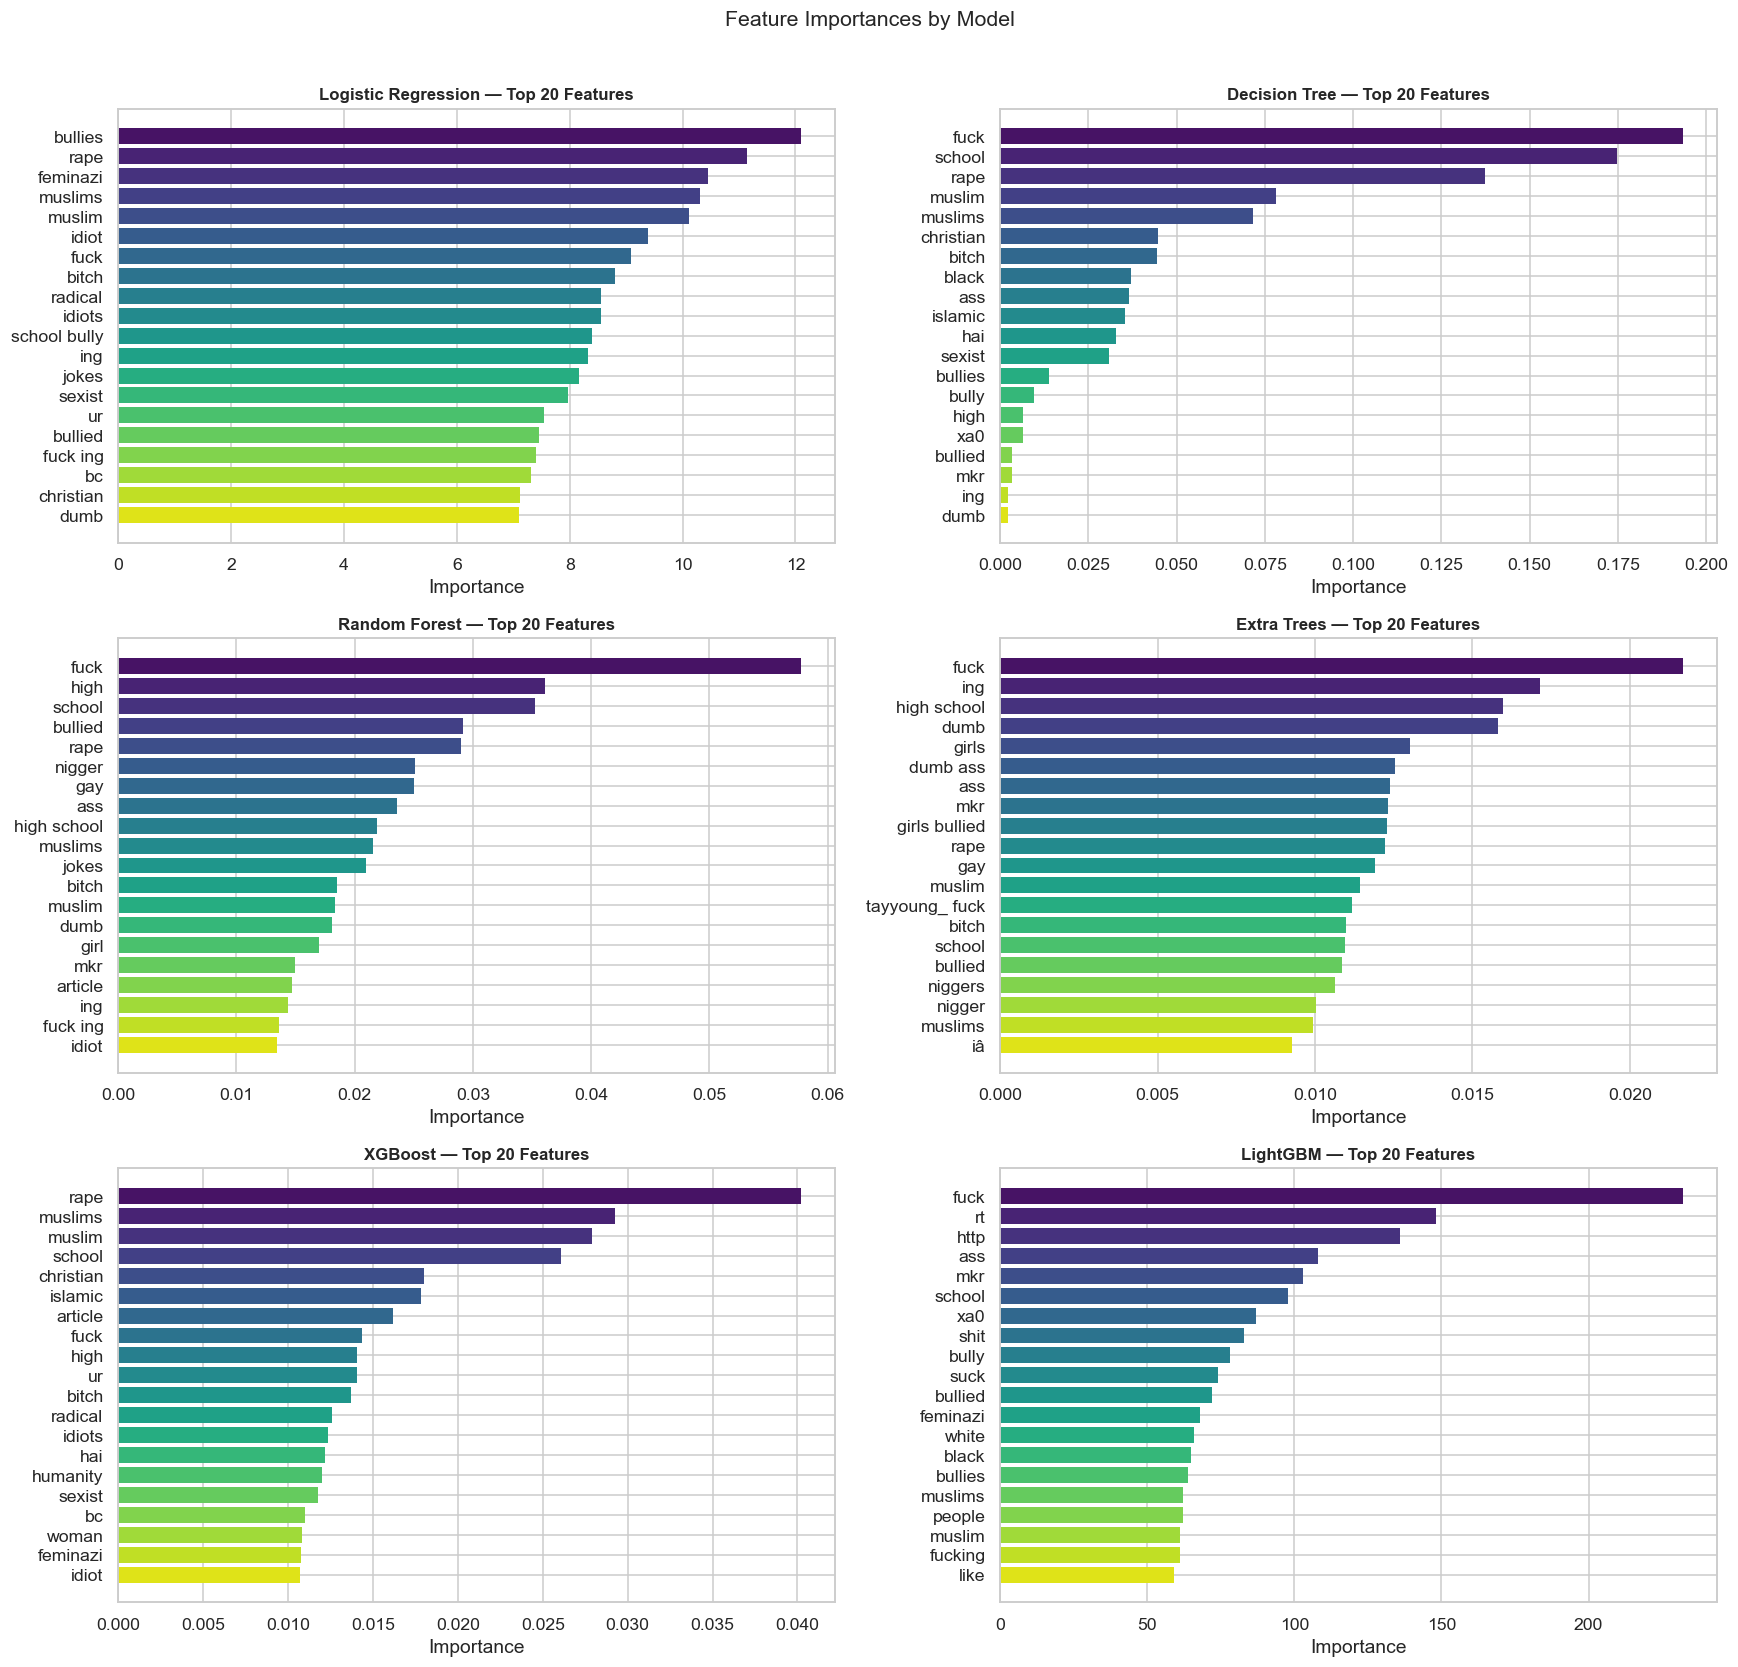

In [69]:
feature_names = np.array(vectorizer.get_feature_names_out())
importance_models = {
    k: v for k, v in trained.items()
    if hasattr(v, 'feature_importances_') or hasattr(v, 'coef_')
}

cols = 2
rows = (len(importance_models) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 8, rows * 5))
axes = axes.flatten() if rows * cols > 1 else [axes]

for i, (name, model) in enumerate(importance_models.items()):
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    else:  # coef_ (LogReg)
        imp = np.abs(model.coef_[0])

    top_idx  = np.argsort(imp)[-20:][::-1]
    top_feats = feature_names[top_idx]
    top_imps  = imp[top_idx]

    color = sns.color_palette('viridis', 20)
    axes[i].barh(top_feats[::-1], top_imps[::-1], color=color[::-1], edgecolor='none')
    axes[i].set_title(f'{name} — Top 20 Features', fontsize=11)
    axes[i].set_xlabel('Importance')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Importances by Model', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [70]:
for name, model in trained.items():
    y_pred = model.predict(X_test)
    print(f'{'─'*55}')
    print(f'  {name}')
    print(f'{'─'*55}')
    print(classification_report(y_test, y_pred,
                                target_names=['Safe', 'Threat'],
                                digits=4))
    print()

───────────────────────────────────────────────────────
  Naive Bayes
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

        Safe     0.7706    0.5674    0.6535      7434
      Threat     0.8439    0.9326    0.8860     18642

    accuracy                         0.8285     26076
   macro avg     0.8072    0.7500    0.7698     26076
weighted avg     0.8230    0.8285    0.8198     26076


───────────────────────────────────────────────────────
  Logistic Regression
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

        Safe     0.6842    0.8788    0.7694      7434
      Threat     0.9455    0.8382    0.8886     18642

    accuracy                         0.8498     26076
   macro avg     0.8148    0.8585    0.8290     26076
weighted avg     0.8710    0.8498    0.8546     26076


───────────────────────────────────────────────────────
  Decision Tree
────────────

E:\anacode3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best model by F1: Logistic Regression

5-Fold F1 scores : ['0.8526', '0.8483', '0.8469', '0.8520', '0.8479']
Mean F1          : 0.8495 ± 0.0023


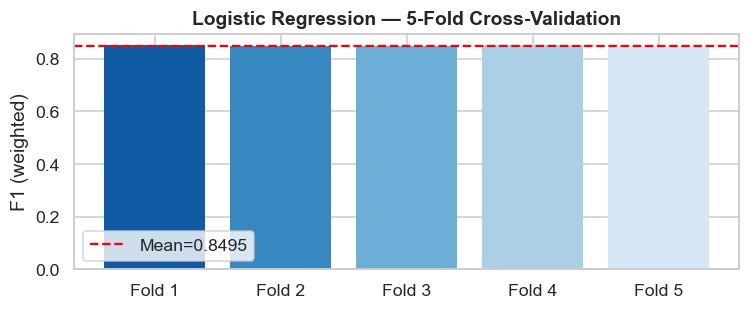

In [71]:
best_name = results_df.iloc[0]['Model']
best_model = trained[best_name]

print(f'Best model by F1: {best_name}')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Use full (non-SMOTE) data for honest CV
cv_scores = cross_val_score(
    best_model,
    vectorizer.transform(df['headline']),
    df['label'],
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1
)

print(f'\n5-Fold F1 scores : {[f"{s:.4f}" for s in cv_scores]}')
print(f'Mean F1          : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(1, 6), cv_scores, color=sns.color_palette('Blues_r', 5), edgecolor='none')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean={cv_scores.mean():.4f}')
ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax.set_ylabel('F1 (weighted)')
ax.set_title(f'{best_name} — 5-Fold Cross-Validation')
ax.legend()
plt.tight_layout()
plt.show()

In [72]:
print('  FINAL LEADERBOARD  (sorted by F1 Score)')
print('-' * 83)
display_df = results_df.copy()
for col in ['Accuracy','Precision','Recall','F1 Score','ROC-AUC','MCC']:
    display_df[col] = display_df[col].map('{:.4f}'.format)
display_df['Train Time(s)'] = display_df['Train Time(s)'].map('{:.2f}s'.format)
print(display_df.to_string(index=False))
print()
print(f'Best model : {best_name}')

  FINAL LEADERBOARD  (sorted by F1 Score)
-----------------------------------------------------------------------------------
              Model Accuracy Precision Recall F1 Score ROC-AUC    MCC Train Time(s)
Logistic Regression   0.8498    0.8710 0.8498   0.8546  0.9298 0.6719         1.05s
        Naive Bayes   0.8285    0.8230 0.8285   0.8198  0.9108 0.5543         0.02s
            XGBoost   0.7986    0.8605 0.7986   0.8080  0.9032 0.6172        46.87s
           LightGBM   0.7970    0.8605 0.7970   0.8066  0.9038 0.6160         7.19s
      Random Forest   0.7583    0.8453 0.7583   0.7700  0.8968 0.5643         2.25s
        Extra Trees   0.7509    0.8498 0.7509   0.7629  0.9044 0.5653         1.78s
      Decision Tree   0.6915    0.8343 0.6915   0.7043  0.7814 0.4989         4.23s

Best model : Logistic Regression
